# NB03 - Métricas, calibración y bondad de ajuste con Titanic

Aquí evaluamos el modelo como clasificador probabilístico: matriz de confusión, ROC, precision-recall, calibración, Hosmer-Lemeshow y selección de umbral.


In [1]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks_2":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "processed"

pd.set_option("display.max_columns", 80)
pd.set_option("display.precision", 4)

from scipy.stats import chi2
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)

from src.titanic_utils import RANDOM_STATE, load_processed_splits, set_plot_style

set_plot_style()
data = load_processed_splits(DATA_DIR)
X_train = data["X_train_processed"]
X_test = data["X_test_processed"]
y_train = data["y_train"]
y_test = data["y_test"]


## 1. Modelo base y matriz de confusión

Usamos `penalty="l2"` con `C=1.0`, el valor por defecto de scikit-learn. En scikit-learn, `C` controla de forma inversa la fuerza de regularización: valores pequeños significan penalización fuerte; valores grandes, penalización débil. `max_iter=1000` evita detener el solver antes de converger.


In [2]:
base_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
    random_state=RANDOM_STATE,
)
base_model.fit(X_train, y_train)

y_prob = base_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

metrics = pd.Series(
    {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_prob),
        "log_loss": log_loss(y_test, y_prob),
    }
)
display(metrics.to_frame("valor"))


,valor
accuracy,0.8022
balanced_accuracy,0.7865
precision,0.7551
recall,0.7184
f1,0.7363
auc,0.8551
log_loss,0.4452


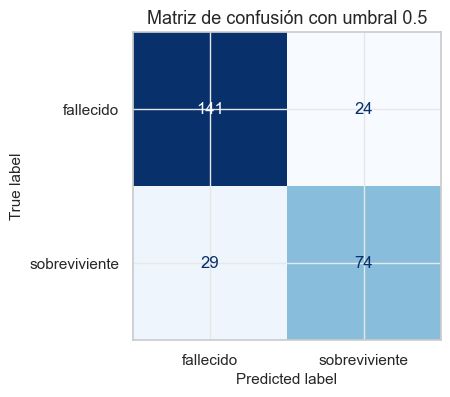

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["fallecido", "sobreviviente"],
    cmap="Blues",
    ax=ax,
    colorbar=False,
)
ax.set_title("Matriz de confusión con umbral 0.5")
plt.show()


## 2. Curva ROC y AUC

La ROC resume sensibilidad y especificidad para todos los umbrales. Es útil, pero puede verse optimista cuando hay desbalance fuerte; por eso también miramos precision-recall.


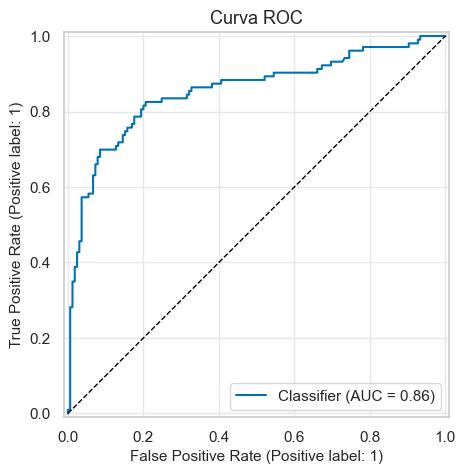

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
ax.set_title("Curva ROC")
plt.show()


## 3. Curva precision-recall

La curva precision-recall se enfoca en la clase positiva: supervivencia. Es especialmente informativa cuando los costos de detectar o no detectar supervivientes son asimétricos.


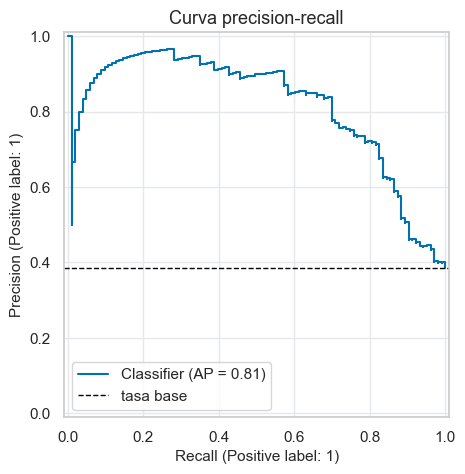

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax)
ax.axhline(y_test.mean(), linestyle="--", color="black", linewidth=1, label="tasa base")
ax.legend()
ax.set_title("Curva precision-recall")
plt.show()


## 4. Calibración

Un modelo bien calibrado produce probabilidades que corresponden a frecuencias observadas. `n_bins=8` equilibra resolución y tamaño de muestra por grupo en este dataset pequeño.


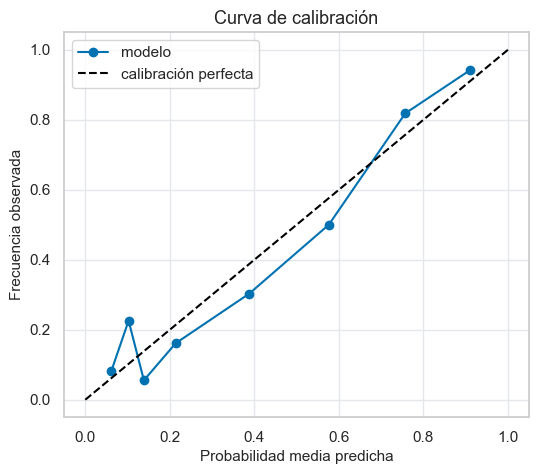

In [6]:
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=8, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(prob_pred, prob_true, marker="o", label="modelo")
ax.plot([0, 1], [0, 1], linestyle="--", color="black", label="calibración perfecta")
ax.set_title("Curva de calibración")
ax.set_xlabel("Probabilidad media predicha")
ax.set_ylabel("Frecuencia observada")
ax.legend()
plt.show()


## 5. Test de Hosmer-Lemeshow desde cero

Agrupamos por deciles de probabilidad predicha (`g=10`). El test compara eventos observados y esperados dentro de cada grupo. Debe leerse como diagnóstico aproximado, no como veredicto absoluto.


In [7]:
def hosmer_lemeshow(y_true, y_prob, g=10):
    hl_df = pd.DataFrame({"y": np.asarray(y_true), "prob": np.asarray(y_prob)})
    hl_df["grupo"] = pd.qcut(hl_df["prob"], q=g, duplicates="drop")
    grouped = hl_df.groupby("grupo", observed=True)

    table = grouped.agg(
        n=("y", "size"),
        observados_1=("y", "sum"),
        esperados_1=("prob", "sum"),
        prob_media=("prob", "mean"),
    )
    table["observados_0"] = table["n"] - table["observados_1"]
    table["esperados_0"] = table["n"] - table["esperados_1"]

    eps = 1e-12
    statistic = (
        ((table["observados_1"] - table["esperados_1"]) ** 2) / (table["esperados_1"] + eps)
        + ((table["observados_0"] - table["esperados_0"]) ** 2) / (table["esperados_0"] + eps)
    ).sum()
    dof = max(len(table) - 2, 1)
    p_value = 1 - chi2.cdf(statistic, dof)
    return statistic, dof, p_value, table


hl_stat, hl_dof, hl_p, hl_table = hosmer_lemeshow(y_test, y_prob, g=10)
print(f"Hosmer-Lemeshow: chi2={hl_stat:.3f}, gl={hl_dof}, p-value={hl_p:.4f}")
display(hl_table)


Hosmer-Lemeshow: chi2=7.847, gl=8, p-value=0.4485


,n,observados_1,esperados_1,prob_media,observados_0,esperados_0
grupo,,,,,,
"(0.0019299999999999999, 0.0817]",27,3,1.4200,0.0526,24,25.5800
"(0.0817, 0.103]",27,4,2.5615,0.0949,23,24.4385
"(0.103, 0.129]",27,3,3.1587,0.1170,24,23.8413
"(0.129, 0.178]",27,2,4.1115,0.1523,25,22.8885
"(0.178, 0.272]",26,5,5.7802,0.2223,21,20.2198
"(0.272, 0.469]",27,7,9.9404,0.3682,20,17.0596
"(0.469, 0.593]",26,11,13.6225,0.5239,15,12.3775
"(0.593, 0.741]",27,20,18.0885,0.6699,7,8.9115
"(0.741, 0.867]",27,22,21.7147,0.8042,5,5.2853


## 6. El umbral de decisión

El umbral 0.5 solo es óptimo bajo supuestos fuertes de costos y prevalencias. Barrer umbrales muestra el intercambio entre precisión, recall, F1 y balanced accuracy.


,threshold,precision,recall,f1,balanced_accuracy
31,0.36,0.7143,0.8252,0.7658,0.8096
33,0.38,0.7143,0.8252,0.7658,0.8096
32,0.37,0.7143,0.8252,0.7658,0.8096
34,0.39,0.7179,0.8155,0.7636,0.8078
51,0.56,0.8372,0.6990,0.7619,0.8071
35,0.40,0.7155,0.8058,0.7580,0.8029
41,0.46,0.7297,0.7864,0.7570,0.8023
40,0.45,0.7297,0.7864,0.7570,0.8023
36,0.41,0.7193,0.7961,0.7558,0.8011
30,0.35,0.6967,0.8252,0.7556,0.8005


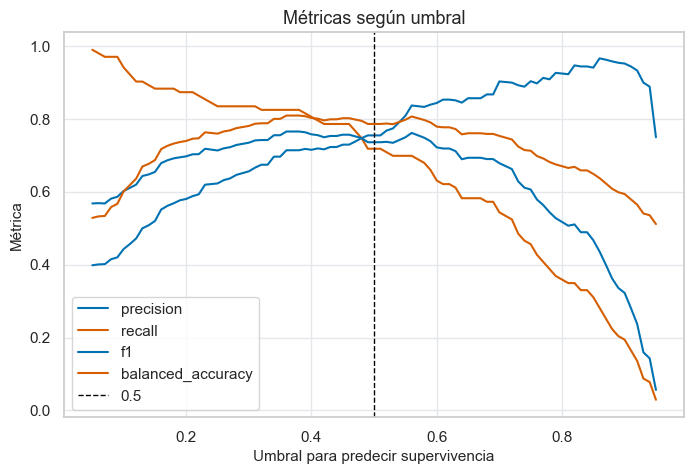

In [8]:
thresholds = np.linspace(0.05, 0.95, 91)
rows = []
for threshold in thresholds:
    pred = (y_prob >= threshold).astype(int)
    rows.append(
        {
            "threshold": threshold,
            "precision": precision_score(y_test, pred, zero_division=0),
            "recall": recall_score(y_test, pred),
            "f1": f1_score(y_test, pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        }
    )
threshold_df = pd.DataFrame(rows)
display(threshold_df.sort_values("f1", ascending=False).head(10))

fig, ax = plt.subplots(figsize=(8, 5))
for metric in ["precision", "recall", "f1", "balanced_accuracy"]:
    ax.plot(threshold_df["threshold"], threshold_df[metric], label=metric)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="0.5")
ax.set_title("Métricas según umbral")
ax.set_xlabel("Umbral para predecir supervivencia")
ax.set_ylabel("Métrica")
ax.legend()
plt.show()


## Resumen y conexión con la literatura

Un modelo logístico produce probabilidades; la clasificación es una decisión posterior. ROC, PR, calibración, Hosmer-Lemeshow y barrido de umbrales cubren dimensiones distintas del desempeño, en línea con Hosmer-Lemeshow, Hosmer et al. y la literatura de desbalance.
